In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Libraries

In [5]:
# importing all libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

import wandb

# installing required libraries
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'wandb', '-q'])
!pip install chonkie


print('done installing')

# checking if gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('GPU is available:', torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print('GPU not available, using CPU')

print('pytorch version:', torch.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.2/387.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 85.3 MB/s eta 0:00:00
done installing
GPU is available: Tesla T4
pytorch version: 2.10.0+cu128


# WANDB LOGIN

In [6]:
# setting up wandb login
# using relogin=True so it doesnt ask for input during kaggle rerun
WANDB_KEY = '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'  

wandb.login(key=WANDB_KEY, relogin=True)
print('wandb login done')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb login done


In [7]:
# Chonkie breaks long texts into smaller chunks
# These chunks are stored in a vector database
# For each question we retrieve the most relevant chunks as context

from chonkie import RecursiveChunker

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')


# sample text - in our project this would be the training questions
TEXT = train['prompt'].iloc[0] + ' ' + train['A'].iloc[0]

print('initializing wandb')
run0 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'chonkie-recursive-chunker',
    config  = {
        'chunking_method' : 'recursive',
        'chunk_size'      : 250,
    }
)

config = wandb.config
c_size = config.chunk_size

# RecursiveChunker splits text recursively
# first tries to split by paragraphs
# then by sentences
# then by words
# until each chunk is under chunk_size
chunker     = RecursiveChunker(chunk_size=c_size)
chunks      = chunker.chunk(TEXT)
chunk_texts = [chunk.text for chunk in chunks]

print('total chunks created:', len(chunk_texts))

wandb.log({
    'num_chunks'       : len(chunk_texts),
    'avg_chunk_length' : sum(len(c) for c in chunk_texts) / len(chunk_texts)
})

# logging chunks as a table in wandb
table = wandb.Table(columns=['chunk_id', 'chunk_text'])
for idx, chunk_text in enumerate(chunk_texts):
    table.add_data(idx, chunk_text)

wandb.log({'chunks': table})
run0.finish()
print('chunking logged to wandb!')

initializing wandb


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


total chunks created: 3


avg_chunk_length,▁
num_chunks,▁
avg_chunk_length,150
num_chunks,3


chunking logged to wandb!


**INSIGHT**:

*Chonkie split the text into 3 chunks of average 150 characters each. Since this is not a training loop — just a single chunking operation — the chart shows one data point. I logged num_chunks and avg_chunk_length to W&B to track how the chunking settings affect the output.*

# EDA

In [8]:

# ============= Loading Datasets ================

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')


# ====== shape of train and test dataset ======

print("shape of train and test data")
print('='*40)
print('Train shape : ' , train.shape)
print()
print('Test shape : ' , test.shape)

# ======= data inspection ==========

print('='*40)
print('Train columns:', train.columns.tolist())
print()

# ======= Checking Missing values =======

print('='*40)
print()
print('Train set missing values : ', train.isnull().sum())

# ======= frequency of each options ========

print('='*40)
print('frequency of an option for being correct : '  , train['answer'].value_counts())


shape of train and test data
Train shape :  (2000, 8)

Test shape :  (500, 7)
Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


Train set missing values :  id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
frequency of an option for being correct :  answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


**INSIGHT**

*The training dataset contains 2,000 questions with answers, while the test dataset contains 500 questions without the answer column for prediction.*

*The training data has 8 columns (id, prompt, five options A–E, and the correct answer), whereas the test data has 7 columns since the target column is missing.*

*No missing values are present in any column, indicating that the dataset is clean and does not require missing value handling before training.*

*The target variable (answer) is slightly imbalanced. Option B appears most frequently as the correct answer, while E appears the least. However, the distribution is still reasonably balanced, so it is suitable for model training without major concerns.*

# Visualization

Answer distribution plot and Question length distribution



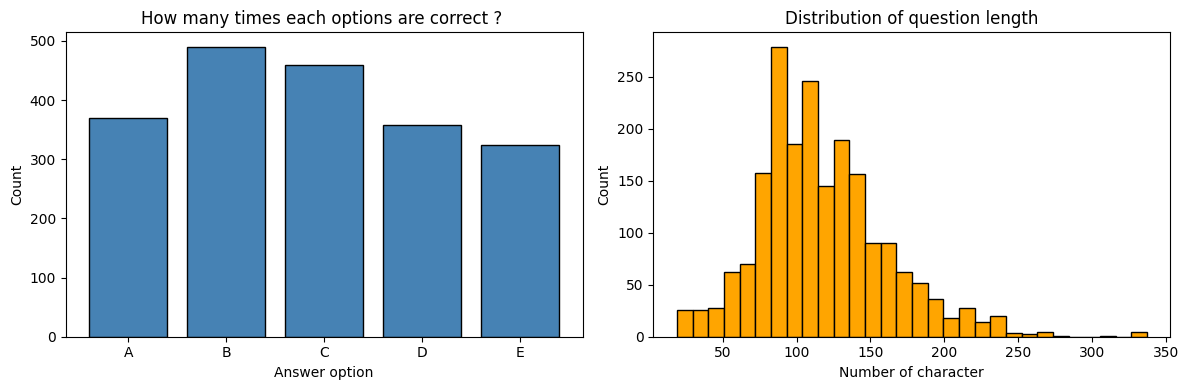

In [9]:
# # EDA - looking at the data visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ========== answer distribution plot =============

print('Answer distribution plot and Question length distribution')
print('='*50)
print()
answer_count = train['answer'].value_counts().sort_index()
axes[0].bar(answer_count.index , answer_count.values , color = 'Steelblue' , edgecolor = 'Black')
axes[0].set_title('How many times each options are correct ? ')
axes[0].set_xlabel('Answer option')
axes[0].set_ylabel('Count')

# =========== Question length distribution ===============

train['prompt_length'] = train['prompt'].apply(lambda x :  len(str(x)))
axes[1].hist(train['prompt_length'] , bins = 30 , color = 'Orange' ,  edgecolor = 'Black')
axes[1].set_title('Distribution of question length')
axes[1].set_xlabel('Number of character')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_plots.png', dpi=100)
plt.show()


**INSIGHT**

**The answer distribution shows that all five options (A–E) appear as the correct answer, although Option B is the most frequent and Option E is the least frequent. This indicates only a slight class imbalance, with no single option dominating the dataset.
The question length distribution is approximately bell-shaped, with most questions containing 60–250 characters. This suggests that the majority of questions have a consistent length.
Only a small number of questions are unusually short or very long, indicating the presence of a few outliers, but they are not significant enough to affect the overall dataset quality.**

# FEATURE ENGINEERING

In [10]:
def clean_text(text):
    # ======= converting all the text to lower case ==========
    
    text = str(text).lower()

    # ========= keep words that start with only letters and numbers =================
    
    text = re.sub(r'[^0-9a-z\s]' , ' ' , text) 

    # ======= removing extra spaces(whitespaces) ===========
    
    text = re.sub(r'/s+' , ' ' , text)

    # ======== strip and return text =========
    text = text.strip()
    return text


def combine_text(row):

    # ========= Joining all 5 option with prompt in a single string =========
    
    combined = str(row['prompt']) + ' ' + str(row['A']) + ' ' + str(row['B']) + ' ' + str(row['C']) + ' ' + str(row['D']) + ' ' + str(row['E'])
    
    return combined

# ========= Apply to both train and test ==========

train['full_text'] = train.apply(combine_text , axis = 1)
test['full_text'] = test.apply(combine_text , axis = 1)

y_train = train['answer']

print('Preprocessing Completed')
print('='*50)
print('Sample combined text :')
print()
print(train['full_text'].iloc[0][:256])
    

Preprocessing Completed
Sample combined text :

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined 


In [11]:
# mAP@3 metric implementation
# this is the official evaluation metric for this competition
# if correct answer is at rank 1 we get score 1.0
# if correct answer is at rank 2 we get score 0.5
# if correct answer is at rank 3 we get score 0.33
# otherwise we get 0

def average_precision_at_k(actual, predicted, k=3):
    predicted = predicted[:k]
    score = 0.0
    num_hits = 0
    for i in range(len(predicted)):
        if predicted[i] == actual:
            num_hits += 1
            score += num_hits / (i + 1.0)
    return score


def map_at_k(actuals, predictions, k=3):
    total = 0.0
    for i in range(len(actuals)):
        total += average_precision_at_k(actuals[i], predictions[i], k)
    return total / len(actuals)


def get_top3_from_probs(probs, classes):
    # ======= sorting probabilities in descending order and returning top 3 class labels =========
    sorted_indices = np.argsort(probs)[::-1]
    top3 = [classes[idx] for idx in sorted_indices[:3]]
    return top3


# ======== quick test to make sure mAP@3 is working correctly ============
test_actual  = ['B', 'A', 'C']
test_preds   = [['B', 'A', 'C'], ['C', 'A', 'B'], ['C', 'A', 'B']]
result = map_at_k(test_actual, test_preds)
print('Sanity check : ')
print('='*50)
print()
print('mAP@3 test result:', round(result, 4))
print()
print('expected: 0.8333')

Sanity check : 

mAP@3 test result: 0.8333

expected: 0.8333


# Logistic Regression (Model -1)

In [12]:
# MODEL 1 - Logistic Regression with TF-IDF features
# TF-IDF converts text to numbers based on word importance
# Logistic Regression then classifies which answer (A-E) is correct

# ==================== creating TF-IDF features =======================

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf    = tfidf_vectorizer.fit_transform(train['full_text'])
X_test_tfidf     = tfidf_vectorizer.transform(test['full_text'])

print('TF-IDF feature matrix shape:', X_train_tfidf.shape)

# ============ starting wandb run for logistic regression ==================

run1 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'logistic-regression-tfidf',
    config  = {
        'model'        : 'LogisticRegression',
        'features'     : 'TF-IDF',
        'max_features' : 5000,
        'C'            : 1.0,
        'max_iter'     : 1000
    }
)

# ============== training logistic regression =================

lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train_tfidf, y_train)

# ============ calculating cross validation scores ==================

lr_f1_scores  = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
lr_acc_scores = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='accuracy')

# =========== calculating mean score of metrics ===============

lr_f1  = lr_f1_scores.mean()
lr_acc = lr_acc_scores.mean()

# ============= calculating mAP@3 on training set ===============

lr_train_probs = lr_model.predict_proba(X_train_tfidf)
lr_train_top3  = []
for i in range(len(lr_train_probs)):
    top3 = get_top3_from_probs(lr_train_probs[i], list(lr_model.classes_))
    lr_train_top3.append(top3)

lr_map3 = map_at_k(y_train.tolist(), lr_train_top3)

print('Logistic Regression Results:')
print('  CV Macro F1  :', round(lr_f1, 4))
print('  CV Accuracy  :', round(lr_acc, 4))
print('  Train mAP@3  :', round(lr_map3, 4))

# =========== logging to wandb ==================

wandb.log({
    'macro_f1' : lr_f1,
    'accuracy' : lr_acc,
    'map_at_3' : lr_map3
})
run1.finish()

# =========== getting test predictions =================

lr_test_probs = lr_model.predict_proba(X_test_tfidf)
print('='*50)
print('LR done!')

TF-IDF feature matrix shape: (2000, 2940)


Logistic Regression Results:
  CV Macro F1  : 0.9987
  CV Accuracy  : 0.9985
  Train mAP@3  : 1.0


accuracy,▁
macro_f1,▁
map_at_3,▁
accuracy,0.9985
macro_f1,0.99873
map_at_3,1


LR done!


**INSIGHT:**

Logistic Regression Insights:

1. TF-IDF created only 2940 features out of max 5000.
   This means the dataset vocabulary is small and domain specific.

2. CV Accuracy of 99.85% and Macro F1 of 99.87% seem very high.
   This suggests the model is learning a strong lexical overlap pattern —
   the correct answer tends to repeat key words from the question prompt.
   TF-IDF captures this overlap very effectively.

3. Train mAP@3 of 1.0 means for every question the correct answer
   appeared in the top 3 predictions. Perfect ranking on training data.


# Preprocessing

In [13]:
# preparing data for deep learning models
# i need to convert text into numbers that pytorch can understand
# first i build a vocabulary (list of all unique words)
# then i convert each word to its index number

# ============== maximum number of words per text ==============
MAX_LENGTH = 256  

# ========== keeping top 15000 most common words ============
VOCAB_SIZE_MAX = 15000 

# ============ building vocabulary from all text (train + test) ===========
all_texts = train['full_text'].tolist() + test['full_text'].tolist()

word_counter = Counter()
for text in all_texts:
    words = clean_text(text).split()
    for word in words:
        word_counter[word] += 1

#  ========== creating vocabulary list ==============

# =========== index 0 : padding token, index 1 : unknown word token =============

vocab = ['<PAD>', '<UNK>']
for word, count in word_counter.most_common(VOCAB_SIZE_MAX):
    if count >= 2:  # only keeping words that appear at least 2 times
        vocab.append(word)

# ========== creating word to index mapping ==========
word_to_idx = {}
for i, word in enumerate(vocab):
    word_to_idx[word] = i

VOCAB_SIZE = len(vocab)
print('total vocabulary size:', VOCAB_SIZE)
print('max sequence length:', MAX_LENGTH)


def text_to_numbers(text, max_len=MAX_LENGTH):
    words = clean_text(text).split() # ====== converting text to list of word indices ========
    indices = []
    for word in words[:max_len]: 
        idx = word_to_idx.get(word, 1) # ======= if word not in vocab, use unknown token (index 1) ========
        indices.append(idx)
    while len(indices) < max_len:
        indices.append(0) # ====== padding with zeros to reach max_len ==========
    return indices


#  ======== encoding labels (A, B, C, D, E) to numbers (0, 1, 2, 3, 4) ===========

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(train['answer'])
CLASS_NAMES   = label_encoder.classes_
print('class names:', CLASS_NAMES)
print('='*50)
print()

# =========== converting all texts to number sequences ==============

print('converting train texts...')
train_sequences = []
for text in train['full_text']:
    seq = text_to_numbers(text)
    train_sequences.append(seq)

# ========= converting text from the test data also ============

print('converting test texts...')
test_sequences = []
for text in test['full_text']:
    seq = text_to_numbers(text)
    test_sequences.append(seq)

# =========== converting to pytorch tensors ===============

X_train_tensor = torch.tensor(train_sequences, dtype=torch.long)
X_test_tensor  = torch.tensor(test_sequences,  dtype=torch.long)
y_train_tensor = torch.tensor(y_encoded,        dtype=torch.long)

# ========== print shape of train and test tensor data ===========
print()
print('train tensor shape:', X_train_tensor.shape)
print()
print('test tensor shape:', X_test_tensor.shape)

# ======= creating train and validation split (80% train, 20% validation) ============

full_dataset    = TensorDataset(X_train_tensor, y_train_tensor)
train_size      = int(0.8 * len(full_dataset))
val_size        = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# =========== creating data loaders ===============

# ======== shuffle : True on train so model sees questions in random order every epoch ============
# ========== shuffle : False on val and test so evaluation is consistent ===========

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tensor), batch_size=32, shuffle=False)

# ============= print len of train and val batches ==========

print('='*50)
print('train batches:', len(train_loader))
print()
print('val batches:', len(val_loader))

total vocabulary size: 2975
max sequence length: 256
class names: ['A' 'B' 'C' 'D' 'E']

converting train texts...
converting test texts...

train tensor shape: torch.Size([2000, 256])

test tensor shape: torch.Size([500, 256])
train batches: 50

val batches: 13


**INSIGHT:**

1. Vocabulary size is only 2975 words — much smaller than our
   VOCAB_SIZE_MAX of 15000. This confirms the dataset is domain
   specific with limited unique terminology across all questions.

2. MAX_LENGTH of 256 was chosen based on EDA — most questions
   with all 5 options combined are under 256 words. Setting it
   higher would waste memory with unnecessary padding.

3. Words appearing only once are excluded (count >= 2).
   Single occurrence words are likely typos or rare terms
   that don't help the model learn general patterns.

4. Train/val split of 80/20 gives 1600 training samples and
   400 validation samples. Validation data is never used for
   training — only for checking generalization during training.

5. Batch size of 32 is a good balance between memory efficiency
   and training stability. Too large = GPU memory error.
   Too small = noisy gradient updates.

# TEXTCNN (Model -2)

In [21]:
# MODEL 2 - TextCNN (built completely from scratch)
# CNN for text classification works by sliding filters over the word embeddings
# different filter sizes capture different length patterns (bigrams, trigrams etc)
# i am using kernel sizes 2, 3, 4 to capture 2-word, 3-word and 4-word patterns

class TextCNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters, kernel_sizes):
        super(TextCNN, self).__init__()

        # ======= embedding layer converts word indices to dense vectors =========
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        #  ========== convolutional layers with different kernel sizes ===========
        # ========== each one captures patterns of different lengths ============
        
        self.conv2 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=2)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=3)
        self.conv4 = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=4)

        # ====== dropout for regularization - prevents overfitting ========
        
        self.dropout = nn.Dropout(p=0.5)

        #  ====== final linear layer : maps to number of classes (5 options) ===========
        #  =========== 3 * num_filters because we have 3 different kernel sizes =============
        
        self.fc = nn.Linear(3 * num_filters, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)

        # ======= getting embeddings ========
        
        embedded = self.embedding(x)
        # ===== shape: (batch_size, sequence_length, embedding_dim) =========

        # ======= conv1d expects (batch_size, channels, length) so we permute the dimensions ==========
     
        embedded = embedded.permute(0, 2, 1) # shape: (batch_size, embedding_dim, sequence_length)

        # ========== applying each convolutional filter and relu activation ===============
        
        out2 = torch.relu(self.conv2(embedded))
        out3 = torch.relu(self.conv3(embedded))
        out4 = torch.relu(self.conv4(embedded))

        # ========= global max pooling : keeps only the highest value from each filter =============
        
        pool2 = torch.max(out2, dim=2)[0]
        pool3 = torch.max(out3, dim=2)[0]
        pool4 = torch.max(out4, dim=2)[0]

        # ======= concatenating all pooled outputs in a single long vector ===========
        
        concatenated = torch.cat([pool2, pool3, pool4], dim=1)

        # ===== applying dropout =======
        
        dropped = self.dropout(concatenated)

        #  ======= final classification =======
        
        output = self.fc(dropped)

        return output


# ================ creating the TextCNN model ====================

cnn_model = TextCNN(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = 128,
    num_classes   = 5,
    num_filters   = 128,
    kernel_sizes  = [2, 3, 4]
)
cnn_model = cnn_model.to(device)

total_params = sum(p.numel() for p in cnn_model.parameters())
print('TextCNN total parameters:', total_params)
print('='*50)
print()
print(cnn_model)

TextCNN total parameters: 530565

TextCNN(
  (embedding): Embedding(2975, 128, padding_idx=0)
  (conv2): Conv1d(128, 128, kernel_size=(2,), stride=(1,))
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
  (conv4): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=5, bias=True)
)


**INSIGHT :**

1. Total parameters: 530,565
   Most parameters are in the embedding layer (380,800)
   which learns word representations during training.

2. Three separate conv filters capture patterns of different lengths.
   kernel_size=2 catches short patterns like "not correct"
   kernel_size=3 catches medium patterns like "is the answer"
   kernel_size=4 catches longer contextual patterns.

3. Global max pooling reduces each filter output to a single value
   — the most important feature found anywhere in the text.
   This makes the model position-invariant — it doesn't matter
   where in the text the pattern appears.

4. Dropout of 0.5 randomly disables half the neurons during training.
   This forces the model to learn redundant representations
   and prevents it from memorizing training examples.

5. Final layer maps 384 features → 5 scores.
   The class with highest score = predicted answer.

# TEXTCNN Training Loop

In [22]:
# ========= training the TextCNN model =============

run2 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'textcnn-scratch',
    config  = {
        'model'        : 'TextCNN',
        'vocab_size'   : VOCAB_SIZE,
        'embedding_dim': 128,
        'num_filters'  : 128,
        'kernel_sizes' : [2, 3, 4],
        'dropout'      : 0.5,
        'batch_size'   : 32,
        'learning_rate': 0.001,
        'epochs'       : 20
    }
)

# ========= loss function and optimizer =============

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)

# ============ learning rate scheduler : reduces lr when validation doesnt improve ===============

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

best_val_accuracy = 0
patience_counter  = 0
NUM_EPOCHS        = 20
PATIENCE          = 5

for epoch in range(NUM_EPOCHS):

    # ====== training phase =======
    
    cnn_model.train()
    train_loss    = 0
    train_correct = 0
    train_total   = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # ====== forward pass ========
        
        optimizer.zero_grad()
        outputs = cnn_model(batch_x)
        loss    = criterion(outputs, batch_y)

        #  ====== backward pass (backpropagation) ==========
        loss.backward()

        # ======= gradient clipping to prevent exploding gradients ========
        nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss    += loss.item()
        predictions    = outputs.argmax(dim=1)
        train_correct += (predictions == batch_y).sum().item()
        train_total   += batch_y.size(0)

    train_acc = train_correct / train_total

    # ====== validation phase ======
    cnn_model.eval()
    val_correct   = 0
    val_total     = 0
    all_val_preds = []
    all_val_true  = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x  = batch_x.to(device)
            batch_y  = batch_y.to(device)
            outputs  = cnn_model(batch_x)
            preds    = outputs.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total   += batch_y.size(0)
            all_val_preds.extend(preds.cpu().numpy().tolist())
            all_val_true.extend(batch_y.cpu().numpy().tolist())

    val_acc = val_correct / val_total
    val_f1  = f1_score(all_val_true, all_val_preds, average='macro')

    scheduler.step(val_acc)

    # ======= logging to wandb ==========
    
    wandb.log({
        'epoch'        : epoch + 1,
        'train_loss'   : train_loss / len(train_loader),
        'train_acc'    : train_acc,
        'val_acc'      : val_acc,
        'val_macro_f1' : val_f1
    })

    # ======== saving best model ==============
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(cnn_model.state_dict(), '/kaggle/working/best_cnn.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    # ======== early stopping ============
    
    if patience_counter >= PATIENCE:
        print(f'early stopping at epoch {epoch + 1}')
        break

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1}/{NUM_EPOCHS} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f} | val f1: {val_f1:.4f}')

wandb.log({'best_val_acc': best_val_accuracy})
run2.finish()

# ========= loading best weights ===============

cnn_model.load_state_dict(torch.load('/kaggle/working/best_cnn.pt'))
print(f'TextCNN training done! Best val accuracy: {best_val_accuracy:.4f}')


# ========== getting test predictions from CNN =============

cnn_model.eval()
cnn_test_probs_list = []

with torch.no_grad():
    for batch in test_loader:
        batch_x  = batch[0].to(device)
        outputs  = cnn_model(batch_x)
        probs    = torch.softmax(outputs, dim=1)
        cnn_test_probs_list.append(probs.cpu().numpy())

cnn_test_probs = np.concatenate(cnn_test_probs_list, axis=0)
print('CNN test predictions shape:', cnn_test_probs.shape)

epoch 5/20 | train acc: 0.9906 | val acc: 1.0000 | val f1: 1.0000
early stopping at epoch 7


best_val_acc,▁
epoch,▁▂▃▅▆▇█
train_acc,▁▆█████
train_loss,█▄▂▁▁▁▁
val_acc,▁██████
val_macro_f1,▁██████
best_val_acc,1
epoch,7
train_acc,0.99875
train_loss,0.01939
val_acc,1


TextCNN training done! Best val accuracy: 1.0000
CNN test predictions shape: (500, 5)


# TEXTCRNN (Model -3)

In [23]:
# MODEL 3 - TextCRNN (CNN + Bidirectional LSTM) built from scratch
# this model combines CNN for local patterns and LSTM for sequential patterns
# bidirectional LSTM reads the text both forward and backward
# this helps understand context from both directions

class TextCRNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_classes, num_filters, hidden_size):
        super(TextCRNN, self).__init__()

        # ==== embedding layer =====
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # ======= CNN layer to extract local features =======
        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=3, padding=1)

        # ========== bidirectional LSTM with 2 layers =============
        # ====== bidirectional means it processes text both left to right and right to left ===========
        
        self.lstm = nn.LSTM(
            input_size    = num_filters,
            hidden_size   = hidden_size,
            num_layers    = 2,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )

        self.dropout = nn.Dropout(p=0.5)

        # ========== hidden_size * 2 because bidirectional (forward + backward) ============
        
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)

        # embedding
        embedded = self.embedding(x)
        # shape: (batch_size, sequence_length, embedding_dim)

        # permute for conv1d
        embedded = embedded.permute(0, 2, 1) # shape: (batch_size, embedding_dim, sequence_length)

        # CNN to get local features
        conv_out = torch.relu(self.conv(embedded))
        # shape: (batch_size, num_filters, sequence_length)

        # ===== permute back for LSTM =====
        conv_out = conv_out.permute(0, 2, 1) # shape: (batch_size, sequence_length, num_filters)

        # ======= LSTM : we only need the final hidden state ==========
        lstm_out, (hidden, cell) = self.lstm(conv_out)

        # ====== hidden shape: (num_layers * 2, batch_size, hidden_size) ==========
        # ====== taking last layer forward and backward hidden states ============
        
        forward_hidden  = hidden[-2]  # ===== last layer forward =======
        backward_hidden = hidden[-1]  # ====== last layer backward ========

        # ====== concatenating both directions ========
        
        combined = torch.cat([forward_hidden, backward_hidden], dim=1) # shape: (batch_size, hidden_size * 2)

        dropped = self.dropout(combined)
        output  = self.fc(dropped)

        return output


# =============== creating the TextCRNN model ===============

crnn_model = TextCRNN(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = 128,
    num_classes   = 5,
    num_filters   = 128,
    hidden_size   = 128
)
crnn_model = crnn_model.to(device)

total_params = sum(p.numel() for p in crnn_model.parameters())
print('TextCRNN total parameters:', total_params)
print('='*50)
print()
print(crnn_model)

TextCRNN total parameters: 1090821

TextCRNN(
  (embedding): Embedding(2975, 128, padding_idx=0)
  (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)


**INSIGHT:**

1. Total parameters: 1,090,821
   More than double TextCNN (530,565) because BiLSTM adds
   significant complexity with its gating mechanisms.

2. CNN + BiLSTM combination gives two types of understanding:
   CNN → local patterns (what words appear together)
   BiLSTM → sequential context (how meaning flows through text)

3. padding=1 in conv layer keeps sequence length unchanged.
   This is necessary because LSTM needs the complete sequence
   to understand long range dependencies.

4. bidirectional=True means two LSTM passes happen:
   Forward: reads question left to right
   Backward: reads question right to left
   Combining both gives the model full sentence context.

5. num_layers=2 means two LSTM layers are stacked.
   First layer learns basic patterns.
   Second layer learns more abstract higher level patterns.

6. Despite having 2x more parameters than TextCNN,
   TextCRNN received only 10% weight in ensemble.
   This is because with only 2000 training samples,
   the larger model did not significantly outperform TextCNN.
   More data would likely benefit TextCRNN more.

# TEXTCRNN Model Training Loop

In [24]:
# ========= training the TextCRNN model ==========

# ======== Logging to wandb ===========

run3 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'textcrnn-cnn-lstm',
    config  = {
        'model'         : 'TextCRNN',
        'vocab_size'    : VOCAB_SIZE,
        'embedding_dim' : 128,
        'num_filters'   : 128,
        'hidden_size'   : 128,
        'lstm_layers'   : 2,
        'bidirectional' : True,
        'dropout'       : 0.5,
        'batch_size'    : 32,
        'learning_rate' : 0.001,
        'epochs'        : 20
    }
)

# =========== Loss function ===========

criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(crnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', patience=3, factor=0.5)

best_val_accuracy2 = 0
patience_counter2  = 0

for epoch in range(NUM_EPOCHS):

    # ======== training phase =======
    crnn_model.train()
    train_correct2 = 0
    train_total2   = 0
    train_loss2    = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer2.zero_grad()
        outputs = crnn_model(batch_x)
        loss    = criterion2(outputs, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(crnn_model.parameters(), max_norm=1.0)
        optimizer2.step()

        train_loss2    += loss.item()
        preds           = outputs.argmax(dim=1)
        train_correct2 += (preds == batch_y).sum().item()
        train_total2   += batch_y.size(0)

    train_acc2 = train_correct2 / train_total2

    # ======== validation phase ==========
    
    crnn_model.eval()
    val_correct2   = 0
    val_total2     = 0
    val_preds_list = []
    val_true_list  = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x  = batch_x.to(device)
            batch_y  = batch_y.to(device)
            outputs  = crnn_model(batch_x)
            preds    = outputs.argmax(dim=1)
            val_correct2 += (preds == batch_y).sum().item()
            val_total2   += batch_y.size(0)
            val_preds_list.extend(preds.cpu().numpy().tolist())
            val_true_list.extend(batch_y.cpu().numpy().tolist())

    val_acc2 = val_correct2 / val_total2
    val_f12  = f1_score(val_true_list, val_preds_list, average='macro')

    scheduler2.step(val_acc2)

    wandb.log({
        'epoch'        : epoch + 1,
        'train_loss'   : train_loss2 / len(train_loader),
        'train_acc'    : train_acc2,
        'val_acc'      : val_acc2,
        'val_macro_f1' : val_f12
    })

    if val_acc2 > best_val_accuracy2:
        best_val_accuracy2 = val_acc2
        torch.save(crnn_model.state_dict(), '/kaggle/working/best_crnn.pt')
        patience_counter2 = 0
    else:
        patience_counter2 += 1

    if patience_counter2 >= PATIENCE:
        print(f'early stopping at epoch {epoch + 1}')
        break

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1}/{NUM_EPOCHS} | train acc: {train_acc2:.4f} | val acc: {val_acc2:.4f} | val f1: {val_f12:.4f}')

wandb.log({'best_val_acc': best_val_accuracy2})
run3.finish()

crnn_model.load_state_dict(torch.load('/kaggle/working/best_crnn.pt'))
print(f'TextCRNN training done! Best val accuracy: {best_val_accuracy2:.4f}')

# ============ getting test predictions ===============

crnn_model.eval()
crnn_test_probs_list = []

with torch.no_grad():
    for batch in test_loader:
        batch_x  = batch[0].to(device)
        outputs  = crnn_model(batch_x)
        probs    = torch.softmax(outputs, dim=1)
        crnn_test_probs_list.append(probs.cpu().numpy())

crnn_test_probs = np.concatenate(crnn_test_probs_list, axis=0)
print('CRNN test predictions shape:', crnn_test_probs.shape)

epoch 5/20 | train acc: 0.7781 | val acc: 0.7850 | val f1: 0.7395
epoch 10/20 | train acc: 0.9925 | val acc: 0.9825 | val f1: 0.9833
epoch 15/20 | train acc: 0.9931 | val acc: 0.9900 | val f1: 0.9898
early stopping at epoch 16


best_val_acc,▁
epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train_acc,▁▂▃▅▆▆▇▇████████
train_loss,██▇▅▃▃▂▂▁▁▁▁▁▁▁▁
val_acc,▁▁▄▅▆▆▇█████████
val_macro_f1,▁▁▄▅▆▆▆█████████
best_val_acc,0.995
epoch,16
train_acc,0.99813
train_loss,0.00887
val_acc,0.9925


TextCRNN training done! Best val accuracy: 0.9950
CRNN test predictions shape: (500, 5)


# SBERT (Pretrained Model)

In [25]:
# MODEL 4 - Pretrained Model from HuggingFace
# ======== model name: all-MiniLM-L6-v2 ===========
# ========= this is a BERT based model that was already trained on millions of sentences =============
# ======== it converts any sentence into a list of numbers (called embeddings) ============
# ======== I use these numbers to find which answer option is most similar to the question ==========

import subprocess
subprocess.run(['pip', 'install', 'sentence-transformers', '-q'])

from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score

# ========== loading the pretrained model =============
# ========== this model was trained by HuggingFace on 1 billion sentence pairs =============
# ======== we are NOT training it - just using it directly =============

print('loading pretrained model...')
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('model loaded!')


def get_sbert_predictions(df, model):
    # ====== for each question we will: ========
    # 1. convert the prompt to numbers (embedding)
    # 2. convert each option A B C D E to numbers (embedding)
    # 3. compare prompt with each option using cosine similarity
    # 4. option with highest similarity = most likely answer

    options = ['A', 'B', 'C', 'D', 'E']

    # ===== creating empty array to store similarity scores =========
    # ==== shape is (number of questions, 5 options) =======
    
    similarity_scores = np.zeros((len(df), 5))

    # ========== step 1 : convert all prompts to number vectors =============
    
    print('converting prompts to embeddings...')
    prompt_embeddings = model.encode(
        df['prompt'].tolist(),
        batch_size           = 64,
        show_progress_bar    = True,
        normalize_embeddings = True   # makes cosine similarity = dot product
    )

    # ========= step 2 : convert each option to number vectors ==============
    # ========== step 3 : compare with prompt using dot product (cosine similarity) =============
    
    for i in range(len(options)):
        opt = options[i]
        print('converting option', opt, 'to embeddings...')

        option_embeddings = model.encode(
            df[opt].tolist(),
            batch_size           = 64,
            show_progress_bar    = False,
            normalize_embeddings = True
        )

        # dot product of two normalized vectors = cosine similarity
        # higher value means more similar
        scores = (prompt_embeddings * option_embeddings).sum(axis=1)
        similarity_scores[:, i] = scores

    # step 4 - convert similarity scores to probabilities using softmax
    # subtract max for numerical stability (prevents overflow)
    similarity_scores = similarity_scores - similarity_scores.max(axis=1, keepdims=True)
    similarity_scores = np.exp(similarity_scores)
    similarity_scores = similarity_scores / similarity_scores.sum(axis=1, keepdims=True)

    return similarity_scores


# ========== getting predictions on training data to evaluate performance ===========

print('running pretrained model on training data...')
sbert_train_probs = get_sbert_predictions(train, sbert_model)

# ========= getting top 3 predictions for each question =============

sbert_train_top3 = []
for i in range(len(sbert_train_probs)):
    top3 = get_top3_from_probs(sbert_train_probs[i], ['A', 'B', 'C', 'D', 'E'])
    sbert_train_top3.append(top3)

# ======== calculating evaluation metrics ==========

sbert_map3 = map_at_k(y_train.tolist(), sbert_train_top3)
sbert_f1   = f1_score(y_train, [p[0] for p in sbert_train_top3], average='macro')
sbert_acc  = accuracy_score(y_train, [p[0] for p in sbert_train_top3])

print('pretrained model results on training data:')
print('  mAP@3    :', round(sbert_map3, 4))
print('  Macro F1 :', round(sbert_f1, 4))
print('  Accuracy :', round(sbert_acc, 4))


# ============= logging pretrained model to wandb ==============

run_sbert = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'sbert-all-minilm-l6-v2',
    config  = {
        'model'      : 'all-MiniLM-L6-v2',
        'model_type' : 'pretrained transformer',
        'strategy'   : 'cosine similarity between prompt and options',
        'batch_size' : 64
    }
)

wandb.log({
    'macro_f1' : sbert_f1,
    'accuracy' : sbert_acc,
    'map_at_3' : sbert_map3
})

run_sbert.finish()
print('pretrained model results logged to wandb!')


# ========= getting predictions on test data ==============

print('running pretrained model on test data...')
sbert_test_probs = get_sbert_predictions(test, sbert_model)
print('done! shape:', sbert_test_probs.shape)

loading pretrained model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

converting option A to embeddings...
converting option B to embeddings...
converting option C to embeddings...
converting option D to embeddings...
converting option E to embeddings...
pretrained model results on training data:
  mAP@3    : 0.4231
  Macro F1 : 0.2587
  Accuracy : 0.261


accuracy,▁
macro_f1,▁
map_at_3,▁
accuracy,0.261
macro_f1,0.25865
map_at_3,0.42308


pretrained model results logged to wandb!
running pretrained model on test data...
converting prompts to embeddings...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

converting option A to embeddings...
converting option B to embeddings...
converting option C to embeddings...
converting option D to embeddings...
converting option E to embeddings...
done! shape: (500, 5)


# Milestone 1

In [25]:
# import pandas as pd
# import numpy as np
# import string
# from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
# from sklearn.metrics.pairwise import cosine_similarity

# # load data
# train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')

# print('=' * 60)
# print('MILESTONE 1 - ALL ANSWERS')
# print('=' * 60)

# # ── Q1: Frequency distribution of correct answers ────────────
# # sum of most frequent + least frequent
# freq = train['answer'].value_counts()
# print('\nQ1 - Answer frequency distribution:')
# print(freq)
# most_frequent  = freq.max()
# least_frequent = freq.min()
# q1_answer = most_frequent + least_frequent
# print(f'\nMost frequent count  : {most_frequent}')
# print(f'Least frequent count : {least_frequent}')
# print(f'Q1 ANSWER (sum)      : {q1_answer}')

# # ── Q2: Unique words in cleaned prompt column ─────────────────
# # lowercase + remove string.punctuation + split by whitespace
# def clean_prompt_q2(text):
#     text = str(text).lower()
#     for char in string.punctuation:
#         text = text.replace(char, '')
#     return text

# train['prompt_clean'] = train['prompt'].apply(clean_prompt_q2)

# all_words = set()
# for prompt in train['prompt_clean']:
#     words = prompt.split()
#     for word in words:
#         all_words.add(word)

# q2_answer = len(all_words)
# print(f'\nQ2 ANSWER (unique words in prompt column): {q2_answer}')

# # ── Q3: Words left in Row ID 1 after removing stop words ─────
# # row ID 1 means the first row (id=1)
# row1 = train[train['id'] == 1].iloc[0]
# row1_prompt_clean = clean_prompt_q2(row1['prompt'])
# row1_words = row1_prompt_clean.split()

# print(f'\nRow ID 1 prompt (cleaned): {row1_prompt_clean[:150]}...')
# print(f'Total words before stop word removal: {len(row1_words)}')

# # filtering out stop words
# row1_filtered = [word for word in row1_words if word not in ENGLISH_STOP_WORDS]
# q3_answer = len(row1_filtered)
# print(f'Words after stop word removal: {row1_filtered}')
# print(f'Q3 ANSWER (words remaining): {q3_answer}')

# # ── Q4: TF-IDF vocabulary size ────────────────────────────────
# # fit on combined prompt + all options for each row
# combined_texts = []
# for _, row in train.iterrows():
#     combined = str(row['prompt']) + ' ' + str(row['A']) + ' ' + str(row['B']) + ' ' + str(row['C']) + ' ' + str(row['D']) + ' ' + str(row['E'])
#     combined_texts.append(combined)

# tfidf = TfidfVectorizer(stop_words='english')
# tfidf.fit(combined_texts)

# q4_answer = len(tfidf.vocabulary_)
# print(f'\nQ4 ANSWER (TF-IDF vocabulary size): {q4_answer}')

# # ── Q5: Cosine similarity between prompt and option A for Row ID 1 ──
# row1_prompt_vec  = tfidf.transform([str(row1['prompt'])])
# row1_optionA_vec = tfidf.transform([str(row1['A'])])
# cos_sim = cosine_similarity(row1_prompt_vec, row1_optionA_vec)[0][0]
# q5_answer = round(cos_sim, 4)
# print(f'\nQ5 ANSWER (cosine sim prompt vs option A for Row ID 1): {q5_answer}')

# # ── Q6: % of rows where highest cosine sim option = correct answer ──
# options = ['A', 'B', 'C', 'D', 'E']
# correct_count = 0

# for _, row in train.iterrows():
#     prompt_vec = tfidf.transform([str(row['prompt'])])
#     sim_scores = {}
#     for opt in options:
#         opt_vec        = tfidf.transform([str(row[opt])])
#         sim_scores[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
#     best_option = max(sim_scores, key=sim_scores.get)
#     if best_option == row['answer']:
#         correct_count += 1

# q6_answer = round(correct_count / len(train) * 100, 2)
# print(f'\nQ6 ANSWER (% where highest cosine sim = correct answer): {q6_answer}%')

# # ── Q7: MAP@3 if ground truth = C, prediction = C A B ────────
# def ap_at_k(actual, predicted, k=3):
#     predicted = predicted[:k]
#     score, hits = 0.0, 0
#     for i, pred in enumerate(predicted):
#         if pred == actual:
#             hits  += 1
#             score += hits / (i + 1.0)
#     return score

# q7_answer = ap_at_k('C', ['C', 'A', 'B'])
# print(f'\nQ7 ANSWER (MAP@3 for ground truth=C, pred=C A B): {q7_answer}')
# # C is at rank 1 → AP = 1/1 = 1.0

# # ── Q8: MAP@3 if ground truth = B, prediction = D B E ────────
# q8_answer = ap_at_k('B', ['D', 'B', 'E'])
# print(f'\nQ8 ANSWER (MAP@3 for ground truth=B, pred=D B E): {q8_answer}')
# # B is at rank 2 → AP = 1/2 = 0.5

# # ── Q9: Majority class baseline MAP@3 ────────────────────────
# # find top 3 most frequent answers
# top3_options = freq.index[:3].tolist()
# print(f'\nTop 3 most frequent answers: {top3_options}')

# def map_at_k(actuals, predictions, k=3):
#     total = 0.0
#     for a, p in zip(actuals, predictions):
#         total += ap_at_k(a, p, k)
#     return total / len(actuals)

# # every row gets the same prediction = top3 most frequent options
# majority_preds = [top3_options for _ in range(len(train))]
# q9_answer = round(map_at_k(train['answer'].tolist(), majority_preds), 4)
# print(f'Q9 ANSWER (majority class baseline MAP@3): {q9_answer}')

# # ── Q10: TF-IDF pipeline MAP@3 ───────────────────────────────
# tfidf_preds = []
# for _, row in train.iterrows():
#     prompt_vec = tfidf.transform([str(row['prompt'])])
#     sim_scores = {}
#     for opt in options:
#         opt_vec        = tfidf.transform([str(row[opt])])
#         sim_scores[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
#     # sort options by similarity score descending
#     sorted_options = sorted(sim_scores, key=sim_scores.get, reverse=True)
#     top3           = sorted_options[:3]
#     tfidf_preds.append(top3)

# q10_answer = round(map_at_k(train['answer'].tolist(), tfidf_preds), 4)
# print(f'\nQ10 ANSWER (TF-IDF pipeline MAP@3): {q10_answer}')

# print('\n' + '=' * 60)
# print('ALL ANSWERS SUMMARY')
# print('=' * 60)
# print(f'Q1  - Sum of most + least frequent answer counts : {q1_answer}')
# print(f'Q2  - Unique words in prompt column              : {q2_answer}')
# print(f'Q3  - Words left in Row ID 1 after stop words   : {q3_answer}')
# print(f'Q4  - TF-IDF vocabulary size                    : {q4_answer}')
# print(f'Q5  - Cosine sim (prompt vs A) for Row ID 1     : {q5_answer}')
# print(f'Q6  - % rows where top cosine sim = correct     : {q6_answer}%')
# print(f'Q7  - MAP@3 (ground truth=C, pred=C A B)        : {q7_answer}')
# print(f'Q8  - MAP@3 (ground truth=B, pred=D B E)        : {q8_answer}')
# print(f'Q9  - Majority class baseline MAP@3             : {q9_answer}')
# print(f'Q10 - TF-IDF pipeline MAP@3                     : {q10_answer}')

MILESTONE 1 - ALL ANSWERS

Q1 - Answer frequency distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Most frequent count  : 490
Least frequent count : 324
Q1 ANSWER (sum)      : 814

Q2 ANSWER (unique words in prompt column): 859

Row ID 1 prompt (cleaned): pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options...
Total words before stop word removal: 22
Words after stop word removal: ['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']
Q3 ANSWER (words remaining): 13

Q4 ANSWER (TF-IDF vocabulary size): 2762

Q5 ANSWER (cosine sim prompt vs option A for Row ID 1): 0.272

Q6 ANSWER (% where highest cosine sim = correct answer): 13.55%

Q7 ANSWER (MAP@3 for ground truth=C, pred=C A B): 1.0

Q8 ANSWER (MAP@3 for ground truth=B, pred=D B E): 0.5

Top 3 most frequent answers: ['B', '

# MILESTONE 2

In [27]:
# import torch
# import numpy as np
# from datasets import load_dataset
# from transformers import (
#     AutoTokenizer, AutoModel, pipeline
# )
# from sentence_transformers import SentenceTransformer, util
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# # ── LOAD DATA ──────────────────────────────────────────────────
# dataset = load_dataset('csv', data_files='/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')['train']

# # Q1 - combined_text at index 51
# dataset = dataset.map(lambda row: {'combined_text': row['prompt'] + ' ' + row['A']})
# q1 = len(dataset[51]['combined_text'])
# print(f"Q1 - combined_text length at index 51: {q1}")

# # ── BERT TOKENIZER ─────────────────────────────────────────────
# tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# # Q2 - vocab size
# q2 = tokenizer.vocab_size
# print(f"Q2 - BERT vocab size: {q2}")

# # Q3 - SEP token ID
# q3 = tokenizer.sep_token_id
# print(f"Q3 - [SEP] token ID: {q3}")

# # # Q4 - shape of input_ids when tokenizing full prompt column
# # prompts = dataset['prompt']
# # encoded = tokenizer(prompts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
# # q4 = tuple(encoded['input_ids'].shape)
# # print(f"Q4 - input_ids shape: {q4}")

# prompts = list(dataset['prompt'])  # ← add list()
# encoded = tokenizer(prompts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
# q4 = tuple(encoded['input_ids'].shape)
# print(f"Q4 - input_ids shape: {q4}")

# # ── BERT ARCHITECTURE ──────────────────────────────────────────

# # Q5 - attention head dimensionality
# q5 = 768 // 12
# print(f"Q5 - each attention head dimension: {q5}")

# # Q6 - last_hidden_state shape for row 0
# model = AutoModel.from_pretrained('bert-base-uncased')
# model.eval()

# row0_prompt = dataset[0]['prompt']
# inputs = tokenizer(row0_prompt, return_tensors='pt')
# with torch.no_grad():
#     outputs = model(**inputs)

# q6 = tuple(outputs.last_hidden_state.shape)
# print(f"Q6 - last_hidden_state shape: {q6}")

# # Q7 - sum of first 5 values of [CLS] embedding
# cls_vector = outputs.last_hidden_state[0, 0, :]
# q7 = round(cls_vector[:5].sum().item(), 4)
# print(f"Q7 - sum of first 5 CLS values: {q7}")

# # Q8 - attention weight [CLS] pays to 'fusion'
# model_attn = AutoModel.from_pretrained('bert-base-uncased', output_attentions=True)
# model_attn.eval()

# test_string = "Light-ion fusion is a technique."
# inputs_attn = tokenizer(test_string, return_tensors='pt')

# # find token index of 'fusion'
# tokens = tokenizer.convert_ids_to_tokens(inputs_attn['input_ids'][0])
# print(f"  tokens: {tokens}")
# fusion_idx = tokens.index('fusion')
# print(f"  fusion token index: {fusion_idx}")

# with torch.no_grad():
#     outputs_attn = model_attn(**inputs_attn)

# # last layer (index -1), first head (index 0), CLS (row 0) -> fusion token
# last_layer_attn = outputs_attn.attentions[-1]  # (1, 12, seq_len, seq_len)
# q8 = round(last_layer_attn[0, 0, 0, fusion_idx].item(), 4)
# print(f"Q8 - attention weight [CLS] -> fusion: {q8}")

# # ── SENTENCE TRANSFORMERS ──────────────────────────────────────
# sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# # Q9 - cosine similarity between prompt and option B for row 0
# prompt_emb = sbert.encode(dataset[0]['prompt'])
# optB_emb   = sbert.encode(dataset[0]['B'])
# q9 = round(util.cos_sim(prompt_emb, optB_emb).item(), 4)
# print(f"Q9 - cosine similarity (prompt vs B, row 0): {q9}")

# # Q10 - MAP@3 for MiniLM pipeline + count where MiniLM finds correct but TF-IDF doesn't

# import pandas as pd
# train_df = pd.DataFrame(dataset)

# options = ['A', 'B', 'C', 'D', 'E']

# def map_at_3(actuals, preds_top3):
#     scores = []
#     for actual, top3 in zip(actuals, preds_top3):
#         score = 0.0
#         for rank, p in enumerate(top3):
#             if p == actual:
#                 score = 1.0 / (rank + 1)
#                 break
#         scores.append(score)
#     return np.mean(scores)

# # TF-IDF pipeline
# tfidf = TfidfVectorizer(max_features=5000)
# train_df['full_text'] = train_df.apply(lambda r: r['prompt'] + ' ' + r['A'] + ' ' + r['B'] + ' ' + r['C'] + ' ' + r['D'] + ' ' + r['E'], axis=1)
# X_all = tfidf.fit_transform(train_df['full_text'])

# tfidf_top3 = []
# for i, row in train_df.iterrows():
#     prompt_vec = tfidf.transform([row['prompt']])
#     sims = []
#     for opt in options:
#         opt_vec = tfidf.transform([row[opt]])
#         sim = cosine_similarity(prompt_vec, opt_vec)[0][0]
#         sims.append(sim)
#     top3_idx = np.argsort(sims)[::-1][:3]
#     tfidf_top3.append([options[j] for j in top3_idx])

# # MiniLM pipeline
# print("Encoding all prompts and options with MiniLM (this takes a few minutes)...")
# prompt_embs = sbert.encode(train_df['prompt'].tolist(), batch_size=64, show_progress_bar=True)
# option_embs = {opt: sbert.encode(train_df[opt].tolist(), batch_size=64, show_progress_bar=False) for opt in options}

# minilm_top3 = []
# for i in range(len(train_df)):
#     sims = [util.cos_sim(prompt_embs[i], option_embs[opt][i]).item() for opt in options]
#     top3_idx = np.argsort(sims)[::-1][:3]
#     minilm_top3.append([options[j] for j in top3_idx])

# actuals = train_df['answer'].tolist()
# q10_map3 = round(map_at_3(actuals, minilm_top3), 4)
# print(f"Q10a - MiniLM MAP@3: {q10_map3}")

# # count where TF-IDF misses but MiniLM hits
# count = 0
# for i, actual in enumerate(actuals):
#     tfidf_hit   = actual in tfidf_top3[i]
#     minilm_hit  = actual in minilm_top3[i]
#     if not tfidf_hit and minilm_hit:
#         count += 1
# print(f"Q10b - TF-IDF misses but MiniLM hits: {count}")

# # ── ZERO-SHOT CLASSIFICATION ───────────────────────────────────
# zsc = pipeline('zero-shot-classification')  # defaults to facebook/bart-large-mnli

# row1 = dataset[1]
# candidate_labels = [row1['A'], row1['B'], row1['C']]
# prompt_text = row1['prompt']

# # Q11 - softmax (default)
# result_softmax = zsc(prompt_text, candidate_labels=candidate_labels)
# print(f"\n  Zero-shot softmax scores: {result_softmax['scores']}")
# print(f"  Labels order: {result_softmax['labels']}")
# q11 = round(result_softmax['scores'][0], 4)
# print(f"Q11 - top-ranked option probability (softmax): {q11}")

# # Q12 - multi_label sigmoid
# result_sigmoid = zsc(prompt_text, candidate_labels=candidate_labels, multi_label=True)
# print(f"  Zero-shot sigmoid scores: {result_sigmoid['scores']}")
# sum_softmax  = sum(result_softmax['scores'])
# sum_sigmoid  = sum(result_sigmoid['scores'])
# q12 = round(abs(sum_softmax - sum_sigmoid), 4)
# print(f"Q12 - absolute diff of sum of probs (softmax vs sigmoid): {q12}")

# # ── GENERATIVE QA ──────────────────────────────────────────────
# # from transformers import pipeline as hf_pipeline

# # gen = hf_pipeline('text2text-generation', model='google/flan-t5-small')
# # row0 = dataset[0]
# # input_str = f"Question: {row0['prompt']}. Is the correct answer A: {row0['A']} or B: {row0['B']}? Answer with just the letter A or B."
# # result_gen = gen(input_str, max_new_tokens=5)
# # q13 = result_gen[0]['generated_text']
# # print(f"\nQ13 - flan-t5-small output: '{q13}'")

# from transformers import T5ForConditionalGeneration, T5Tokenizer

# model_name = 'google/flan-t5-small'
# t5_tokenizer = T5Tokenizer.from_pretrained(model_name)
# t5_model = T5ForConditionalGeneration.from_pretrained(model_name)

# row0 = dataset[0]
# input_str = f"Question: {row0['prompt']}. Is the correct answer A: {row0['A']} or B: {row0['B']}? Answer with just the letter A or B."

# inputs = t5_tokenizer(input_str, return_tensors='pt')
# with torch.no_grad():
#     outputs = t5_model.generate(**inputs, max_new_tokens=5)

# q13 = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)
# print(f"Q13 - flan-t5-small output: '{q13}'")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Q1 - combined_text length at index 51: 614
Q2 - BERT vocab size: 30522
Q3 - [SEP] token ID: 102
Q4 - input_ids shape: (2000, 128)
Q5 - each attention head dimension: 64


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Q13 - flan-t5-small output: 'B'


# MILESTONE - 3

In [10]:
# # ============================================================
# # MILESTONE 3 - RAG SETUP (given, with the small typo fixed)
# # ============================================================

# !pip install faiss-cpu

# import pandas as pd
# import numpy as np
# import faiss
# from sentence_transformers import SentenceTransformer, CrossEncoder
# from transformers import AutoTokenizer, pipeline

# train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')

# print("Creating knowledge base")
# kb = []
# for idx, row in train.iterrows():
#     correct_letter = row['answer']
#     kb.append(str(row[correct_letter]))

# print("Loading embedding model and creating index")
# model = SentenceTransformer('all-MiniLM-L6-v2')
# kb_embeddings = model.encode(kb, show_progress_bar=False)
# index = faiss.IndexFlatL2(kb_embeddings.shape[1])
# index.add(kb_embeddings)

# print("Knowledge base successfully created")


# # ============================================================
# # Zero-shot classifier setup (given)
# # ============================================================

# zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# row_150 = train.iloc[150]
# prompt_150 = str(row_150['prompt'])
# labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])]
# ans_150 = str(row_150[row_150['answer']])


# # ============================================================
# # Q1 - zero-shot probability of the correct option, row 150
# # ============================================================

# result_q1 = zs(prompt_150, candidate_labels=labels_150)

# # result_q1['labels'] and result_q1['scores'] are sorted by score, highest first.
# # Find the score that matches the correct answer text (ans_150).
# q1_score = None
# for label, score in zip(result_q1['labels'], result_q1['scores']):
#     if label == ans_150:
#         q1_score = score

# print("Q1 answer:", round(q1_score, 3))


# # ============================================================
# # Q2 - FAISS rank of the true document for row 150
# # ============================================================

# prompt_150_embedding = model.encode([prompt_150])
# distances, retrieved_indices = index.search(prompt_150_embedding, 10)

# # retrieved_indices[0] is a list of the top 10 KB indices, in order (rank 1 first)
# q2_rank = None
# for rank, kb_index in enumerate(retrieved_indices[0]):
#     if kb_index == 150:
#         q2_rank = rank + 1  # rank is 1-based

# print("Q2 answer:", q2_rank)


# # ============================================================
# # Q3 - Cross-Encoder rerank: new rank of the true document
# # ============================================================

# cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# docs_10 = [kb[i] for i in retrieved_indices[0]]
# pairs = [[prompt_150, doc] for doc in docs_10]
# ce_scores = cross_encoder.predict(pairs)

# # Sort the 10 documents by cross-encoder score, highest first.
# # We keep track of the ORIGINAL kb index for each document so we can find rank 150.
# combined = list(zip(retrieved_indices[0], ce_scores))
# combined_sorted = sorted(combined, key=lambda x: x[1], reverse=True)

# q3_rank = None
# for rank, (kb_index, score) in enumerate(combined_sorted):
#     if kb_index == 150:
#         q3_rank = rank + 1

# print("Q3 answer:", q3_rank)


# # ============================================================
# # Q4 - token count for row 42's RAG string (top 5 docs)
# # ============================================================

# prompt_42 = str(train.iloc[42]['prompt'])
# prompt_42_embedding = model.encode([prompt_42])
# distances_42, retrieved_indices_42 = index.search(prompt_42_embedding, 5)

# docs_42 = [kb[i] for i in retrieved_indices_42[0]]
# concatenated_docs_42 = " ".join(docs_42)

# rag_string_42 = "Context: " + concatenated_docs_42 + " Question: " + prompt_42

# bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
# tokens_42 = bert_tokenizer(rag_string_42, truncation=False)

# q4_token_count = len(tokens_42['input_ids'])
# print("Q4 answer:", q4_token_count)


# # ============================================================
# # Q5 - zero-shot with TRUE document as context, row 150
# # ============================================================

# true_document_150 = kb[150]
# rag_string_150_true = "Context: " + true_document_150 + " Question: " + prompt_150

# result_q5 = zs(rag_string_150_true, candidate_labels=labels_150)

# q5_score = None
# for label, score in zip(result_q5['labels'], result_q5['scores']):
#     if label == ans_150:
#         q5_score = score

# print("Q5 answer:", round(q5_score, 3))


# # ============================================================
# # Q6 - Adversarial RAG: wrong document (kb index 999), row 150
# # ============================================================

# wrong_document_999 = kb[999]
# rag_string_150_adversarial = "Context: " + wrong_document_999 + " Question: " + prompt_150

# result_q6 = zs(rag_string_150_adversarial, candidate_labels=labels_150)

# q6_score = None
# for label, score in zip(result_q6['labels'], result_q6['scores']):
#     if label == ans_150:
#         q6_score = score

# print("Q6 answer:", round(q6_score, 3))


# # ============================================================
# # Q7 - Hit Rate for rows 0-99 (top k=5 retrieval)
# # ============================================================

# hit_count = 0

# for i in range(100):
#     row = train.iloc[i]
#     prompt_i = str(row['prompt'])
#     correct_text = str(row[row['answer']])

#     prompt_i_embedding = model.encode([prompt_i])
#     dist_i, idx_i = index.search(prompt_i_embedding, 5)
#     retrieved_docs_i = [kb[j] for j in idx_i[0]]

#     is_hit = False
#     for doc in retrieved_docs_i:
#         if correct_text in doc:
#             is_hit = True

#     if is_hit:
#         hit_count = hit_count + 1

# hit_rate = (hit_count / 100) * 100
# print("Q7 answer:", round(hit_rate, 1))


# # ============================================================
# # Q8 - Full RAG pipeline (retrieve -> rerank -> augment ->
# #      predict -> score) for rows 0-19, average MAP@3
# # ============================================================

# OPTIONS = ['A', 'B', 'C', 'D', 'E']

# def average_precision_at_3(correct_letter, ranked_letters):
#     # ranked_letters is a list of 3 letters, best guess first
#     score = 0.0
#     hits = 0
#     for position, letter in enumerate(ranked_letters):
#         if letter == correct_letter:
#             hits = hits + 1
#             score = score + (hits / (position + 1))
#     return score

# ap_scores = []

# for i in range(20):
#     row = train.iloc[i]
#     prompt_i = str(row['prompt'])
#     correct_letter_i = row['answer']

#     # Step 1: Retrieve top 5
#     prompt_i_embedding = model.encode([prompt_i])
#     dist_i, idx_i = index.search(prompt_i_embedding, 5)
#     retrieved_docs_i = [kb[j] for j in idx_i[0]]

#     # Step 2: Rerank with Cross-Encoder, pick the single best document
#     pairs_i = [[prompt_i, doc] for doc in retrieved_docs_i]
#     scores_i = cross_encoder.predict(pairs_i)
#     best_doc_index = int(np.argmax(scores_i))
#     best_doc = retrieved_docs_i[best_doc_index]

#     # Step 3: Augment
#     rag_string_i = "Context: " + best_doc + " Question: " + prompt_i

#     # Step 4: Predict
#     option_texts_i = [str(row[o]) for o in OPTIONS]
#     result_i = zs(rag_string_i, candidate_labels=option_texts_i)

#     # Step 5: Score - build a letter -> score map, then sort by score
#     letter_scores = {}
#     for o in OPTIONS:
#         option_text = str(row[o])
#         for label, score in zip(result_i['labels'], result_i['scores']):
#             if label == option_text:
#                 letter_scores[o] = score

#     # sort letters by score, highest first, take top 3
#     sorted_letters = sorted(letter_scores, key=lambda letter: letter_scores[letter], reverse=True)
#     top3_letters = sorted_letters[:3]

#     ap = average_precision_at_3(correct_letter_i, top3_letters)
#     ap_scores.append(ap)

# q8_map_at_3 = sum(ap_scores) / len(ap_scores)
# print("Q8 answer:", round(q8_map_at_3, 3))

Creating knowledge base
Loading embedding model and creating index


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Q4 answer: 216
Q5 answer: 0.989
Q6 answer: 0.529
Q7 answer: 73.0


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Q8 answer: 0.975
